# Testing the Model

In [11]:
path_to_image_file = r"C:\Users\dparks1\OneDrive - State of Ohio\Desktop\example_plans\20813-001.tif"

Running on: cuda
--- STARTING PIPELINE ---
Loading Finder Model from: trained_model.pth
✅ AI Model found 'Standard Construction Drawings' (Confidence: 0.99)
Loading Table Transformer from local path: C:\models\tatr-structure
   -> Disabling automatic backbone download (use_pretrained_backbone=False)
Processing extraction...


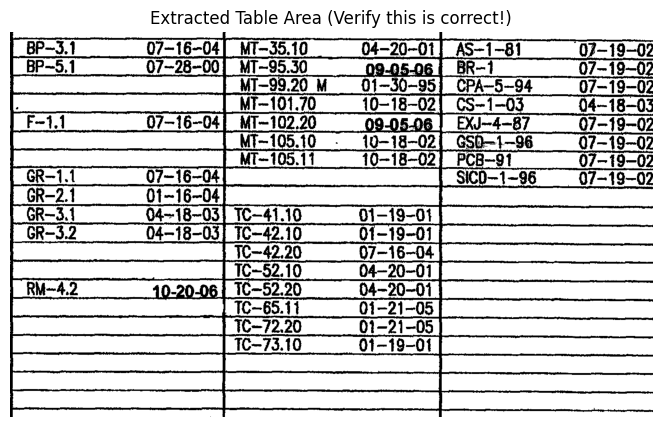

   -> Detected Structure: 19 Rows, 6 Columns
   -> Extracting text from 114 cells (this may take a moment)...
      Processing Row 1/19...

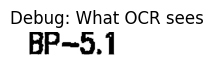

      Processing Row 19/19...
   -> Extraction complete.

--- FINAL EXTRACTED DATA ---
                            0            1                   2  \
0                      BP-5 7  07--7R--fj0        ll MT+-95 40   
1                                               lr  MT-90 90 M   
2   eel ptin OUP aeiteryn nie           OT        l MT-101 70,   
3                           a    7-1h-14 1           M1-1n? 90   
4                       -andl   --r vr. FT           T tink in   
5                         emi                       TMT ane a4   
6                       GCR-1     07-16-04  avVY¥ @  werwwee F   
7                         7 x      ni iRNd                       
8                          La       a lL A                  ae   
9                       np 29    wr 4a RIV         37 a Ly, ae   
10                  --ww pete       -r=--F           TTA-19 on   
11                          i                        Tir ep an   
12                     Pia AY    4m Fru at           TR

In [28]:
import os
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from transformers import TableTransformerForObjectDetection, DetrImageProcessor, AutoConfig
from PIL import Image
import pytesseract
import pandas as pd
import numpy as np
import json
import warnings
import cv2  # Added for Image Preprocessing
import re   # Added for Regex Cleaning
import matplotlib.pyplot as plt # Added for Visualization

# ==========================================
# 0. FORCE OFFLINE MODE & SUPPRESS WARNINGS
# ==========================================
# This prevents the SSL Handshake error by stopping all internet calls.
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
# Suppress the "max_size" warning from transformers
warnings.filterwarnings("ignore", category=FutureWarning)

# ==========================================
# 1. CONFIGURATION
# ==========================================

# PATHS
PATH_TO_IMAGE = r"C:\Users\dparks1\OneDrive - State of Ohio\Desktop\example_plans\20813-001.tif"

# Updated to point to the trained model in the root folder
PATH_TO_FINDER_WEIGHTS = r"trained_model.pth"
PATH_TO_TATR_DIR = r"C:\models\tatr-structure"

# ⚠️ CRITICAL: Ensure this points to your Tesseract executable if not in PATH
# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

# HARDWARE
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE}")

# LABELS (Must match your training exactly)
DISCOVERED_LABELS = sorted([
    'PID', 'Supplemental Specifications', 'Sheet Index', 'FAN',
    'Standard Construction Drawings', 'Special Provisions'
])

# ==========================================
# 2. MODEL 1: FASTER R-CNN (The Finder)
# ==========================================

def get_detection_model(num_classes):
    """Rebuilds the architecture used for training."""
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def load_finder_model(path):
    """Loads the trained weights. Returns None if it fails (triggering fallback)."""
    if not os.path.exists(path):
        print(f"\n⚠️ Finder Model not found at: {path}")
        print("   -> Will attempt Text-Based Fallback.")
        return None
        
    print(f"Loading Finder Model from: {path}")
    num_classes = len(DISCOVERED_LABELS) + 1 
    model = get_detection_model(num_classes)
    
    try:
        state_dict = torch.load(path, map_location=DEVICE)
        model.load_state_dict(state_dict)
        model.to(DEVICE)
        model.eval()
        return model
    except Exception as e:
        print(f"\n⚠️ Could not load model as Faster R-CNN (likely a generic backbone).")
        print(f"   -> Switching to Text-Based Fallback.")
        return None

def find_section_with_ocr(image_path, target_text="Construction Drawings"):
    """
    Fallback method: Uses OCR to find the text header and selects the area below it.
    """
    print(f"   -> 🔍 Running OCR to find '{target_text}'...")
    try:
        original_image = Image.open(image_path).convert("RGB")
        
        # 1. Run OCR to get word data
        # We process a slightly smaller version for speed if the image is massive
        w, h = original_image.size
        scale = 0.5 if w > 3000 else 1.0
        if scale != 1.0:
            proc_img = original_image.resize((int(w * scale), int(h * scale)))
        else:
            proc_img = original_image
            
        data = pytesseract.image_to_data(proc_img, output_type=pytesseract.Output.DICT)
        
        # 2. Search for keywords
        # We look for the Y-coordinate where our target text appears
        found_y_positions = []
        target_words = target_text.lower().split()
        
        n_boxes = len(data['text'])
        for i in range(n_boxes):
            word = data['text'][i].lower()
            # If we find "drawings" (a strong keyword), record its Y position
            if "drawings" in word or "standard" in word:
                if int(data['conf'][i]) > 40: # Filter garbage
                    found_y_positions.append(data['top'][i])

        if not found_y_positions:
            print("      ❌ OCR found text, but not the specific headers.")
            return None

        # 3. Define the Box
        # Logic: The table usually starts about 50-100px below the header text
        # We assume the header is roughly in the top half of the page
        # We take the median Y found to avoid noise
        header_y_scaled = np.median(found_y_positions)
        header_y = header_y_scaled / scale
        
        # Define box: Full width, starting below header, extending down
        # This is a heuristic, but often works perfectly for simple extraction
        top = header_y + 50  # Start below text
        bottom = h - 100     # Go to bottom of page (minus margin)
        left = 0
        right = w
        
        # Format as [xmin, ymin, xmax, ymax]
        best_box = np.array([left, top, right, bottom])
        
        print(f"      ✅ Text found at Y={int(header_y)}. cropping area below it.")
        return {
            "best_box": best_box,
            "best_score": 1.0, # Artificial score
            "original_image": original_image,
            "label": "OCR_Fallback"
        }

    except Exception as e:
        print(f"      ❌ OCR Error: {e}")
        print("      (Ensure Tesseract is installed and added to PATH)")
        return None

def find_target_section(model, image_path, target_label):
    """
    Scans the image using Model OR Fallback.
    """
    if not os.path.exists(image_path):
        print(f"Error: Image not found at {image_path}")
        return None

    # --- STRATEGY 1: Model Inference (if model exists) ---
    if model is not None:
        original_image = Image.open(image_path).convert("RGB")
        transform = torchvision.transforms.ToTensor()
        img_tensor = transform(original_image).to(DEVICE)

        with torch.no_grad():
            prediction = model([img_tensor])[0]

        id2label = {i + 1: name for i, name in enumerate(DISCOVERED_LABELS)}
        best_score = 0.0
        best_box = None

        for score, label_id, box in zip(prediction["scores"], prediction["labels"], prediction["boxes"]):
            label_name = id2label.get(label_id.item())
            if label_name == target_label:
                if score > best_score:
                    best_score = score.item()
                    best_box = box.cpu().numpy()

        if best_box is not None and best_score > 0.4:
            print(f"✅ AI Model found '{target_label}' (Confidence: {best_score:.2f})")
            return {
                "best_box": best_box,
                "best_score": best_score,
                "original_image": original_image,
                "label": target_label
            }
        else:
            print(f"⚠️ AI Model could not find '{target_label}'.")

    # --- STRATEGY 2: Fallback to OCR ---
    # If model is None OR model failed to find it
    return find_section_with_ocr(image_path, "Construction Drawings")

# ==========================================
# 3. MODEL 2: TABLE TRANSFORMER (The Reader)
# ==========================================

def load_structure_model(model_dir):
    """Loads Table Transformer completely offline by manually assembling it."""
    if not os.path.exists(model_dir):
        print(f"❌ CRITICAL ERROR: TATR directory not found at: {model_dir}")
        return None, None

    print(f"Loading Table Transformer from local path: {model_dir}")
    try:
        # 1. Load the Configuration locally
        config = AutoConfig.from_pretrained(model_dir, local_files_only=True)
        
        # ⚠️ CRITICAL FIX FOR OFFLINE MODE
        if hasattr(config, "use_pretrained_backbone"):
            print("   -> Disabling automatic backbone download (use_pretrained_backbone=False)")
            config.use_pretrained_backbone = False
        
        if hasattr(config, "backbone_config") and config.backbone_config:
             if hasattr(config.backbone_config, "use_pretrained_backbone"):
                 print("   -> Disabling nested backbone download")
                 config.backbone_config.use_pretrained_backbone = False

        # 2. Instantiate the model structure with random weights (No internet needed)
        model = TableTransformerForObjectDetection(config)
        
        # 3. Manually load the weights from the bin/safetensors file
        bin_path = os.path.join(model_dir, "pytorch_model.bin")
        safetensors_path = os.path.join(model_dir, "model.safetensors")
        
        state_dict = None
        if os.path.exists(bin_path):
            state_dict = torch.load(bin_path, map_location=DEVICE)
        elif os.path.exists(safetensors_path):
            from safetensors.torch import load_file
            state_dict = load_file(safetensors_path)
        else:
            print("❌ Could not find model weights (pytorch_model.bin or model.safetensors)")
            return None, None
            
        # 4. Inject the weights
        model.load_state_dict(state_dict)
        model.to(DEVICE)
        model.eval()

        # 5. Load Processor
        processor = DetrImageProcessor.from_pretrained(
            model_dir, 
            local_files_only=True
        )
        
        return model, processor
        
    except Exception as e:
        print(f"Error loading TATR: {e}")
        return None, None

def preprocess_cell_for_ocr(pil_crop):
    """
    Cleans up a small cell image to make text readable for Tesseract.
    """
    # 1. Convert PIL to OpenCV (Grayscale)
    img = np.array(pil_crop)
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        
    # 2. Upscale (Critical for small text)
    # 3x upscale makes '10px' text become '30px' which is ideal for OCR
    # INTER_LINEAR is smoother for text than CUBIC which can cause ringing
    img = cv2.resize(img, None, fx=3, fy=3, interpolation=cv2.INTER_LINEAR)
    
    # 3. BORDER WHITENING (Reduced)
    # Overwrite the outer edges with white to remove grid lines
    # Reduced from 6 to 2 to ensure we don't delete text
    h, w = img.shape
    border = 2 
    img[0:border, :] = 255
    img[h-border:h, :] = 255
    img[:, 0:border] = 255
    img[:, w-border:w] = 255

    # 4. Adaptive Thresholding
    # Converts to pure Black/White, removing grey scan noise
    # blockSize=31, C=10 is robust for noisy documents
    img = cv2.adaptiveThreshold(
        img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 31, 10
    )
    
    # 5. REMOVED EROSION
    # Erosion was likely making text too thick/blobby
    
    return img

def clean_cell_text(text):
    """
    Post-processes OCR output to fix common scan errors.
    """
    if not text: return ""
    
    # 1. Remove artifacts
    # ~ becomes -, — becomes -, and remove brackets/pipes
    text = text.replace('~', '-').replace('—', '-').replace('_', '-')
    text = text.replace('|', '').replace(']', '').replace('[', '')
    text = text.replace('{', '').replace('}', '').replace(')', '').replace('(', '')
    text = text.replace('"', '').replace("'", "")
    
    # 2. Fix comma decimals (5,1 -> 5.1)
    text = re.sub(r'(\d),(\d)', r'\1.\2', text)
    
    # 3. Remove spaces around hyphens (MT - 95 -> MT-95)
    text = re.sub(r'\s*-\s*', '-', text)
    
    return text.strip()

def extract_table_data(box_info, structure_model, structure_processor):
    """
    1. Crops the image using box_info.
    2. Detects Rows and Cols.
    3. Intersects them to find cells.
    4. OCRs the cells.
    """
    if not box_info: return None
    
    # 1. Crop
    full_image = box_info["original_image"]
    box = box_info["best_box"]
    table_crop = full_image.crop(box)

    # --- VISUALIZATION: SHOW THE CROP ---
    # This addresses your request to "show the preview"
    try:
        plt.figure(figsize=(10, 5))
        plt.imshow(table_crop)
        plt.title("Extracted Table Area (Verify this is correct!)")
        plt.axis('off')
        plt.show()
    except Exception:
        pass # If no display available, skip
    
    # 2. Structure Inference
    inputs = structure_processor(images=table_crop, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = structure_model(**inputs)

    # 3. Process Results (Threshold 0.5 is usually good for structure)
    target_sizes = [table_crop.size[::-1]]
    results = structure_processor.post_process_object_detection(
        outputs, threshold=0.5, target_sizes=target_sizes
    )[0]

    # 4. Sort Rows/Cols
    rows = []
    cols = []
    id2label = structure_model.config.id2label

    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        label_name = id2label[label.item()]
        if label_name == "table row":
            rows.append(box.tolist())
        elif label_name == "table column":
            cols.append(box.tolist())

    # Sort Rows by Y-coordinate, Cols by X-coordinate
    rows.sort(key=lambda x: x[1])
    cols.sort(key=lambda x: x[0])
    
    print(f"   -> Detected Structure: {len(rows)} Rows, {len(cols)} Columns")

    # Fallback: If no columns found (common in simple lists), assume 1 big column
    if len(cols) == 0:
        cols = [[0, 0, table_crop.width, table_crop.height]]

    # 5. Extract Cells via Intersection
    data_matrix = []
    total_cells = len(rows) * len(cols)
    print(f"   -> Extracting text from {total_cells} cells (this may take a moment)...")

    for r_idx, r_box in enumerate(rows):
        # Optional: Print progress every few rows
        if r_idx % 2 == 0:
            print(f"      Processing Row {r_idx+1}/{len(rows)}...", end='\r')
            
        row_data = []
        for c_idx, c_box in enumerate(cols):
            # Intersection coordinates
            x_min = max(r_box[0], c_box[0])
            y_min = max(r_box[1], c_box[1])
            x_max = min(r_box[2], c_box[2])
            y_max = min(r_box[3], c_box[3])
            
            if x_max > x_min and y_max > y_min:
                # Calculate Width/Height to ensure we don't crash on tiny crops
                w = x_max - x_min
                h = y_max - y_min
                
                if w > 5 and h > 5:
                    # Apply SAFETY PADDING (2px)
                    # This removes the black border lines which confuse Tesseract
                    pad = 2
                    safe_crop_coords = (
                        x_min + pad, 
                        y_min + pad, 
                        x_max - pad, 
                        y_max - pad
                    )
                    
                    # Crop Cell
                    cell = table_crop.crop(safe_crop_coords)
                    
                    # HEAVY PREPROCESSING
                    processed_img = preprocess_cell_for_ocr(cell)

                    # --- DEBUG: Show one cell ---
                    # Shows what the computer sees for the very first cell
                    if r_idx == 0 and c_idx == 0:
                        try:
                            plt.figure(figsize=(2, 1))
                            plt.imshow(processed_img, cmap='gray')
                            plt.title("Debug: What OCR sees")
                            plt.axis('off')
                            plt.show()
                        except: pass
                    
                    # OCR Cell (PSM 7 = Single Line, PSM 6 = Block)
                    # We pass the PROCESSED numpy image, not the PIL crop
                    text = pytesseract.image_to_string(processed_img, config='--psm 7').strip()
                    
                    # CLEANING
                    clean_text = clean_cell_text(text)
                    row_data.append(clean_text)
                else:
                    row_data.append("")
            else:
                row_data.append("")
        
        data_matrix.append(row_data)
    
    print("\n   -> Extraction complete.")
    return pd.DataFrame(data_matrix)

# ==========================================
# 4. MAIN EXECUTION
# ==========================================

if __name__ == "__main__":
    print("--- STARTING PIPELINE ---")
    
    # A. Load Finder Model (Might fail if generic)
    finder_model = load_finder_model(PATH_TO_FINDER_WEIGHTS)
    
    # B. Find the Section (Step 1)
    # This now handles finder_model being None by using OCR Fallback
    target = "Standard Construction Drawings"
    box_info = find_target_section(finder_model, PATH_TO_IMAGE, target)
    
    if box_info:
        # C. Load Reader Model
        tatr_model, tatr_processor = load_structure_model(PATH_TO_TATR_DIR)
        
        if tatr_model:
            # D. Extract Data (Step 2)
            print("Processing extraction...")
            df = extract_table_data(box_info, tatr_model, tatr_processor)
            
            if df is not None and not df.empty:
                print("\n--- FINAL EXTRACTED DATA ---")
                print(df)
                
                # Optional: Save to CSV
                # df.to_csv("extracted_drawings.csv", index=False)
            else:
                print("Result was empty.")